In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Load data once
trips_df = pd.read_parquet("dataset/all_trips.parquet")
stations_df = pd.read_parquet("dataset/all_stations.parquet")

# Trip duration

- Member start more rides then casual users but their rides are shorter, specially in classic bikes.
- Casual users ride more than 2X longer trips than member users.
- Casual users ride 2X longer trips in classic bikes that ebikes.

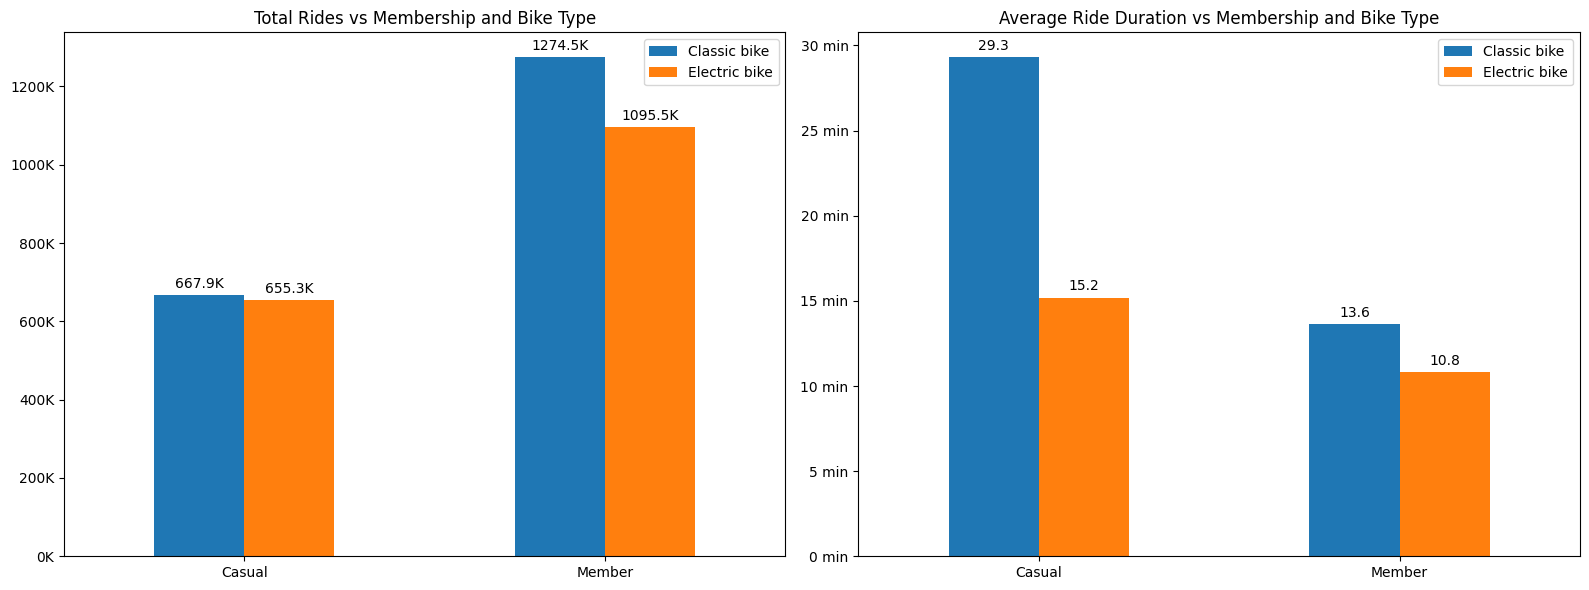

In [24]:
# 1. Prepare Data
duration_per_member_and_bike = trips_df.groupby(['is_member', 'rideable_type'])

# Data for Chart 1: Total Rides (Count)
rides_per_biketype = duration_per_member_and_bike.size().unstack() / 1000

# Data for Chart 2: Average Duration (Mean)
duration_mean_unstacked = (duration_per_member_and_bike['duration'].mean() / 60).unstack()

# 2. Setup Figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Chart 1 Configuration ---
rides_per_biketype.plot(kind='bar', ax=ax1)
ax1.set_title('Total Rides vs Membership and Bike Type')
ax1.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:.0f}K'))
for c in ax1.containers:
    ax1.bar_label(c, fmt='%.1fK', padding=3)

# --- Chart 2 Configuration ---
duration_mean_unstacked.plot(kind='bar', ax=ax2)
ax2.set_title('Average Ride Duration vs Membership and Bike Type')
ax2.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:.0f} min'))
for c in ax2.containers:
    ax2.bar_label(c, fmt='%.1f', padding=3)

# --- Shared Formatting ---
for ax in [ax1, ax2]:
    ax.set_xticklabels(["Casual", "Member"], rotation=0)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.legend(['Classic bike', 'Electric bike'])

plt.tight_layout()
plt.show()


# Number of Rides per Month
- Casual users and members have a similar distribution in initiated rides by month.
- July, August, and September have a peak in rides.
- December, January, and February show the lowest number of rides.

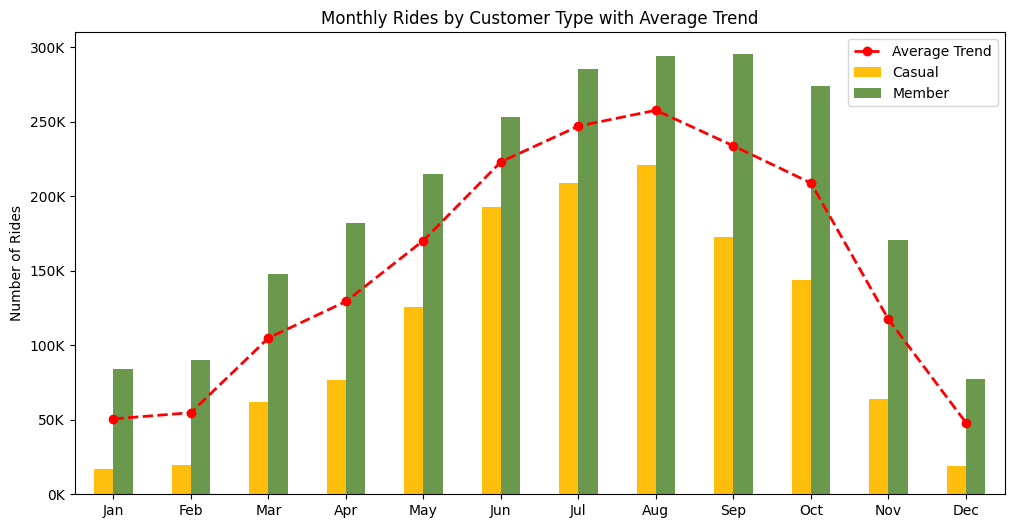

In [70]:
# Set bar chart
number_of_rides_per_month = trips_df.groupby(['month', 'is_member']).size().unstack() / 1000
ax = number_of_rides_per_month.plot(kind='bar', color=['#ffbe0b','#6a994e'], figsize=(12, 6))

# Set trend line
total_rides_month = number_of_rides_per_month.sum(axis=1) / 2
ax.plot(total_rides_month.values, color='red', marker='o', linestyle='--', linewidth=2, label='Average Trend')

# Formatting
ax.set_title('Monthly Rides by Customer Type with Average Trend')
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=0)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:.0f}K'))
ax.legend()
ax.set_xlabel('')
ax.set_ylabel('Number of Rides')
ax.legend(['Average Trend', 'Casual', 'Member'])

plt.show()

# Number of Rides per Weekday

- Members start more rides in weekdays while casual users ride more on weekends.

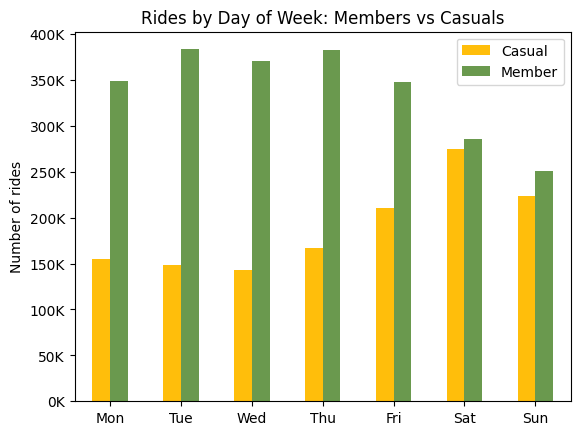

In [29]:
number_of_rides = trips_df.groupby(['day_of_week', 'is_member']).size().unstack() / 1000
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
number_of_rides = number_of_rides.reindex(days_order)

ax = number_of_rides.plot(kind='bar', color=['#ffbe0b','#6a994e'])
ax.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.xticks(rotation=0)
plt.xlabel('')

ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:.0f}K'))
plt.ylabel('Number of rides')
plt.legend(['Casual', 'Member'])
ax.set_title('Rides by Day of Week: Members vs Casuals')
plt.show()

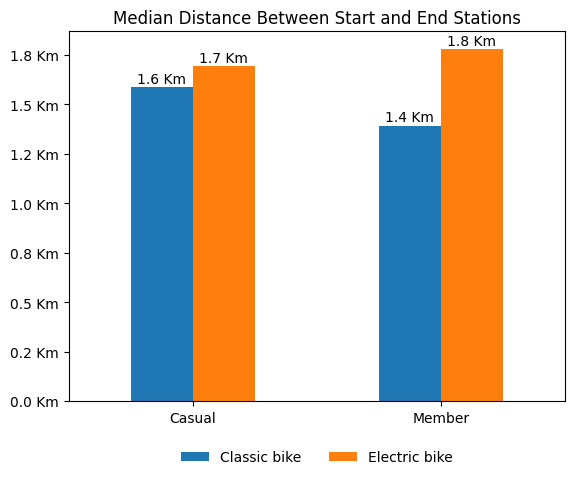

In [17]:
distance_per_member_and_bike = trips_df.groupby(['is_member', 'rideable_type'])['dist_km_simple'].median().unstack()

ax = distance_per_member_and_bike.plot(kind='bar')

ax.set_title('Median Distance Between Start and End Stations')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:.1f} Km'))
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f Km', padding=1)
    
ax.set_xticklabels(["Casual", "Member"], rotation=0)
ax.set_xlabel('')
ax.set_ylabel('')
ax.legend(['Classic bike', 'Electric bike'], loc='upper center', 
          bbox_to_anchor=(0.5, -0.1), # Centered horizontally, below the X-axis
          ncol=3,                     # Puts items in 3 columns (side-by-side)
          frameon=False)

plt.show()

# Station use: Members vs Casual Customers

- Stations around high density and hi traffic areas are mostly used by members.

In [13]:
import folium
import branca.colormap as cm

starts = trips_df[['start_station_id', 'is_member']].rename(columns={'start_station_id': 'station_id'})
ends = trips_df[['end_station_id', 'is_member']].rename(columns={'end_station_id': 'station_id'})
all_station_mentions = pd.concat([starts, ends], axis=0)
all_station_mentions = all_station_mentions.dropna(subset=['station_id'])
unified_member_ratio = all_station_mentions.groupby('station_id')['is_member'].mean().reset_index()
map_data = unified_member_ratio.merge(stations_df, left_on='station_id', right_on='id', how='inner')

heat_data = map_data[['lat', 'lng', 'is_member']].values.tolist()

# Create a Color Step (Red to Green). This maps 0.0 (Casual) to 1.0 (Member)
colormap = cm.LinearColormap(
    colors=['red', 'orange', 'yellow', 'green'],
    vmin=0.0, 
    vmax=1.0,
    caption='Member Proportion (1.0 = 100% Member)'
)

# Initialize the Map
m = folium.Map(location=[map_data['lat'].mean(), map_data['lng'].mean()], 
               zoom_start=10, 
               tiles='cartodbpositron')

# Add CircleMarkers
for _, row in map_data.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lng']],
        radius=6, # This size stays relatively constant
        color=colormap(row['is_member']), # Color determined by proportion
        fill=True,
        fill_color=colormap(row['is_member']),
        fill_opacity=0.7,
        popup=f"Station: {row['name']}<br>Member Proportion: {row['is_member']:.2%}"
    ).add_to(m)

#  Add the Legend to the map
m.add_child(colormap)

m